In [77]:
import numpy as np
import matplotlib.pyplot as plt

In [78]:
N = 50    # sweeps
SEED = 0    # dynamics RNG

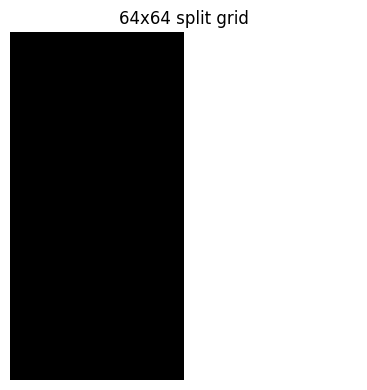

In [79]:
def make_split(size=64):
    """Left half 0 (black), right half 1 (white). Vertical boundary in the middle."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(64)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title("64x64 split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

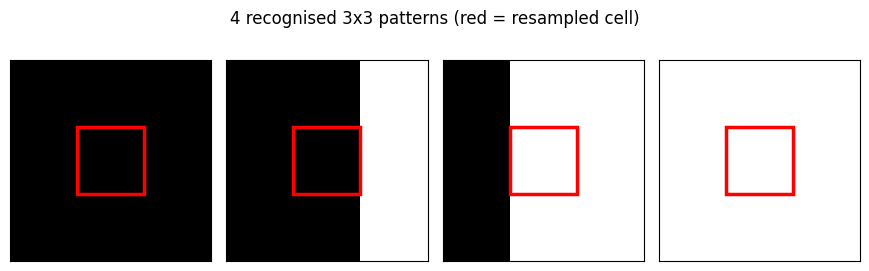

In [80]:
def win_key(w):
    """All nine cells of a 3x3 window, row-major."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """The set of complete 3x3 patterns that occur in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def plot_windows(seen):
    items = sorted(seen)
    fig, axes = plt.subplots(1, len(items), figsize=(2.2 * len(items), 2.8))
    axes = np.atleast_1d(axes)
    for ax, w in zip(axes, items):
        ax.imshow(np.array(w, dtype=float).reshape(3, 3), cmap="gray", vmin=0, vmax=1)
        ax.add_patch(plt.Rectangle((0.5, 0.5), 1, 1, fill=False,
                                   edgecolor="red", lw=2.5))
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{len(items)} recognised 3x3 patterns (red = resampled cell)")
    plt.tight_layout()
    plt.show()


seen = build_windows(grid)
plot_windows(seen)

In [81]:
def step_seq(field, seen, rng):
    """Sequential sweep, sites in random order. For each cell, try both centre
    values; keep whichever make the whole 3x3 a recognised pattern.
    Both work -> coin flip. Neither works -> leave the cell alone."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    unresolved = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2].copy()
        ok = []
        for v in (0, 1):
            w[1, 1] = v
            if win_key(w) in seen:
                ok.append(v)
        if len(ok) == 1:
            field[r, c] = ok[0]
        elif len(ok) == 2:
            field[r, c] = int(rng.random() < 0.5)
        else:
            unresolved += 1
    return field, unresolved


def run(field, seen, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. `field` itself is never modified.
    Prints only when the numbers change."""
    rng = np.random.default_rng(seed)
    original = field.copy()
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, unresolved = step_seq(f, seen, rng)
        state = (int((f != original).sum()), unresolved)
        if verbose and state != prev:
            print(f"  sweep {t:5d}: differing = {state[0]:5d}   unresolved = {state[1]}")
            prev = state
    return f

In [82]:
final_clean = run(grid, seen, verbose=False)
print("fixed point:", np.array_equal(final_clean, grid))

fixed point: True


Noise 10.00%, unrecognised windows left alone:
  sweep     1: differing =   155   unresolved = 1718
  sweep     2: differing =   155   unresolved = 1221


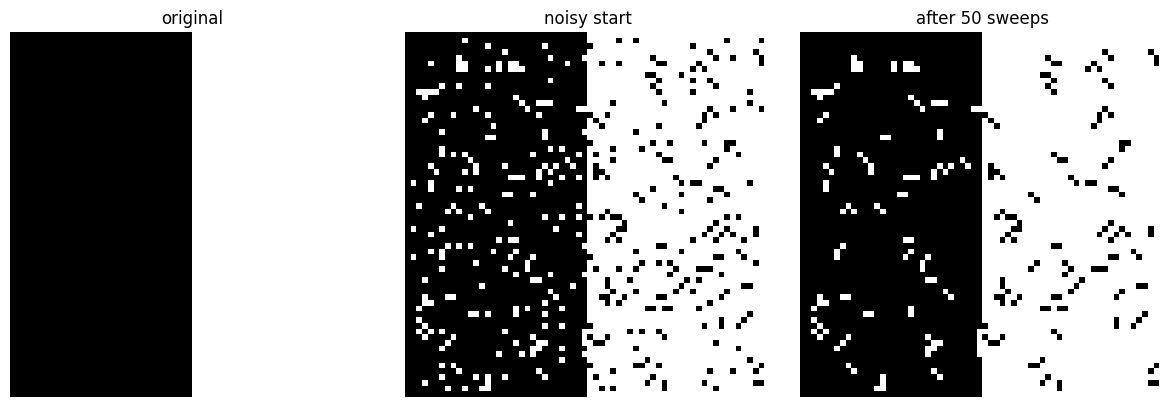

In [83]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


FRAC = 0.1
NOISE_SEED = 1

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
print(f"Noise {FRAC:.2%}, unrecognised windows left alone:")
final_noisy = run(noisy, seen)
plot_three(grid, noisy, final_noisy, N)

So how this code works is we add a fair bit of noise in this case, and we sweep one by one. We look at every single point, and we check its neighbors, and we flip until we find a pattern we recognize. If we never recognize the pattern, it doesn't change. The flaw we have here is we do not consider side neighbors, and so as we can see, chunks or noise particles that are connected by over Two to three to four pieces do not change, and you can actually guess what ones they're going to be. So a fix I could do here is maybe flip all 8 until we recognize the pattern. I'm not sure how plausible that is.Something we could try is to look at the grid, see which one of our recognized patterns it is close to, and then change it to that.  

Here I have gone with the nearest pattern repair method. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N =1000 
SEED = 0     # RNG for sweep order
size = 64# grid size

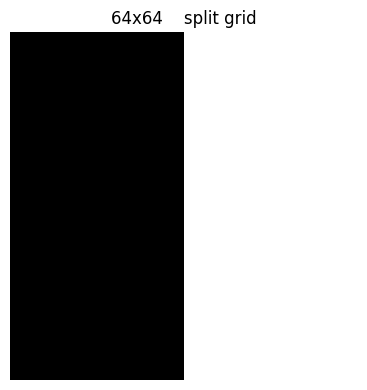

In [3]:
def make_split(size):
    """Left half black (0), right half white (1). One vertical boundary."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(size)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{size}x{size}    split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

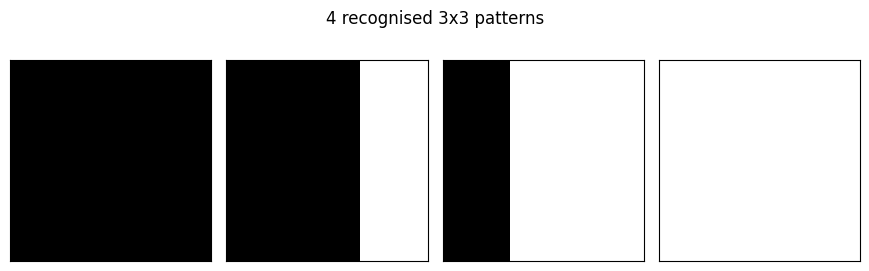

In [4]:
def win_key(w):
    """The nine cells of a 3x3 window, row-major, as a tuple."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """Every complete 3x3 pattern that occurs in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def plot_windows(seen):
    items = sorted(seen)
    fig, axes = plt.subplots(1, len(items), figsize=(2.2 * len(items), 2.8))
    axes = np.atleast_1d(axes)
    for ax, w in zip(axes, items):
        ax.imshow(np.array(w, dtype=float).reshape(3, 3), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{len(items)} recognised 3x3 patterns")
    plt.tight_layout()
    plt.show()


seen = build_windows(grid)
plot_windows(seen)

In [5]:
def pattern_array(seen):
    """Recognised patterns as a (P, 3, 3) int array, in sorted order."""
    return np.array([np.array(p, dtype=int).reshape(3, 3) for p in sorted(seen)])


PATTERNS = pattern_array(seen)


def nearest_pattern(w, patterns):
    """The recognised pattern closest to window w (fewest differing cells).
    Ties: change the centre as little as possible, then lowest sorted order."""
    diffs = (patterns != w).reshape(len(patterns), -1).sum(axis=1)   # Hamming distances
    cands = np.where(diffs == diffs.min())[0]
    if len(cands) > 1:                                               # tie-break 1
        centre_change = (patterns[cands, 1, 1] != w[1, 1]).astype(int)
        cands = cands[centre_change == centre_change.min()]
    return patterns[cands[0]]                                        # tie-break 2: sorted order


def step_seq(field, patterns, rng):
    """One sweep. Visit interior cells in random order; replace each 3x3 window
    with its nearest recognised pattern. Returns (field, cells_changed)."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    changed = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2]
        new = nearest_pattern(w, patterns)
        if not np.array_equal(new, w):
            changed += int((new != w).sum())
            field[r - 1:r + 2, c - 1:c + 2] = new
    return field, changed


def run(field, patterns, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. The input `field` is never modified.
    Prints only when the number of changes moves."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, changed = step_seq(f, patterns, rng)
        if verbose and changed != prev:
            print(f"  sweep {t:5d}: cells changed = {changed}")
            prev = changed
    return f

  sweep     1: cells changed = 1856
  sweep     2: cells changed = 651
  sweep     3: cells changed = 557
  sweep     4: cells changed = 634
  sweep     5: cells changed = 650
  sweep     6: cells changed = 658
  sweep     7: cells changed = 627
  sweep     8: cells changed = 642
  sweep     9: cells changed = 576
  sweep    10: cells changed = 616
  sweep    11: cells changed = 587
  sweep    12: cells changed = 712
  sweep    13: cells changed = 660
  sweep    14: cells changed = 655
  sweep    15: cells changed = 697
  sweep    16: cells changed = 605
  sweep    17: cells changed = 630
  sweep    18: cells changed = 559
  sweep    19: cells changed = 584
  sweep    20: cells changed = 653
  sweep    21: cells changed = 610
  sweep    22: cells changed = 636
  sweep    23: cells changed = 635
  sweep    24: cells changed = 632
  sweep    25: cells changed = 638
  sweep    26: cells changed = 630
  sweep    27: cells changed = 597
  sweep    28: cells changed = 579
  sweep    29: cell

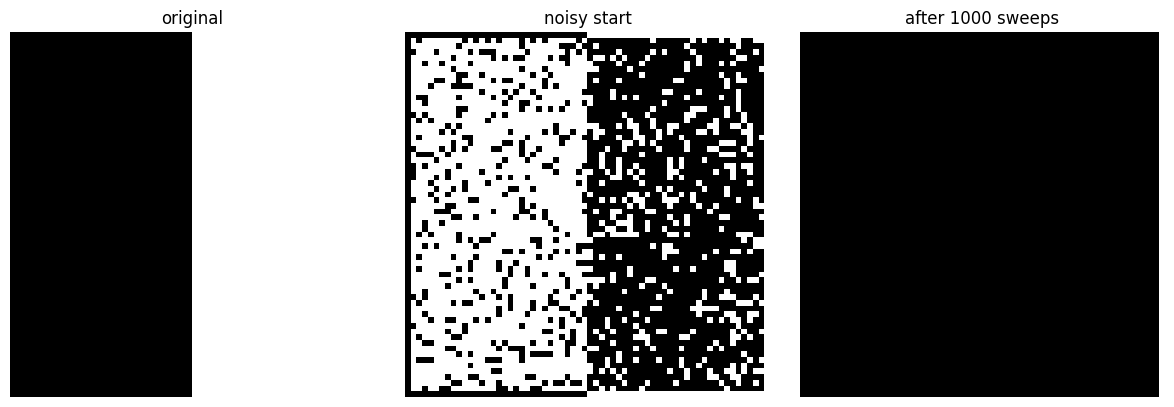

In [6]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


FRAC = 0.8
NOISE_SEED = 15

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final_noisy = run(noisy, PATTERNS)
plot_three(grid, noisy, final_noisy, N)

differing cells per column: [32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55
 56 57 58 59 60 61 62]
column counts: [64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64 64
 64 64 64 64 64 64 64]


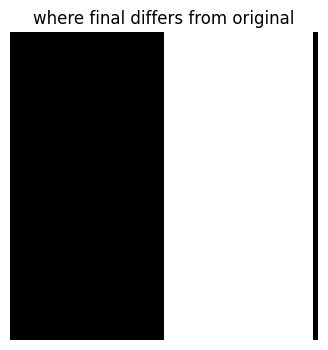

In [7]:
diff = (final_noisy != grid)
print("differing cells per column:", np.where(diff.sum(axis=0) > 0)[0])
print("column counts:", diff.sum(axis=0)[diff.sum(axis=0) > 0])

plt.figure(figsize=(4, 4))
plt.imshow(diff, cmap="gray")
plt.title("where final differs from original")
plt.axis("off")
plt.show()

Repair is perfect, but at a certain point we do see some shift at the boundary. What is also quite interesting as we increase The fraction of cells flipped We see almost a wave pattern reversal. 

Takeaways so far: the center only has a repair radius of 1, so we do tend to get stuck. The whole window nearest pattern works great. But it can cause slight drift, so I will have to try and figure out how to fix that. 

So, full recap so far: first algorithm only flips the center. If you flip and it becomes a recognized pattern, we go with that pattern. If not, nothing changes. 
Second algorithm does the whole window. We compare the current and a pattern that we recognize, and we see the difference between them. I believe it's called the Hamming distance, and whatever pattern we recognize as closer, we will replace it with that. 
Algorithm that we know will try: we'll combine both, so we flip the center to see if that works. If not, fall back to the nearest pattern. 

Our new method is a hybrid approach of our previous two, where in our first we only focus on the center. In our second, we would find the nearest pattern. 

Method 1: the center only one. Never drifts but gets stuck on touching clusters. 
Method 2: a whole window nearest pattern, clears everything but drifts because it rewrites nine cells at a time and can stamp over cells that were already fine. 

Hybrid: For each cell, first try flipping only at the center. If that makes the window recognized, take it. Only if the center flip fails do we fall back to overwriting the whole window with the nearest recognized pattern. 

I think that we will see the center selection do most of the job, and then the second method will fix all stuck positions and potentially drift less now. 

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [34]:
N = 1000
SEED = 0     
size = 64    # grid size

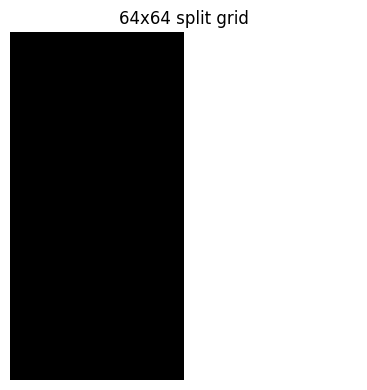

In [35]:
def make_split(size):
    """Left half black (0), right half white (1). One vertical boundary."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(size)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{size}x{size} split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

In [36]:
def win_key(w):
    """The nine cells of a 3x3 window, row-major, as a tuple."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """Every complete 3x3 pattern that occurs in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def pattern_array(seen):
    """Recognised patterns as a (P, 3, 3) int array, in sorted order."""
    return np.array([np.array(p, dtype=int).reshape(3, 3) for p in sorted(seen)])


seen = build_windows(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

4 recognised patterns


In [37]:
def nearest_pattern(w, patterns):
    """The recognised pattern closest to window w (fewest differing cells).
    Ties: change the centre as little as possible, then lowest sorted order."""
    diffs = (patterns != w).reshape(len(patterns), -1).sum(axis=1)
    cands = np.where(diffs == diffs.min())[0]
    if len(cands) > 1:
        centre_change = (patterns[cands, 1, 1] != w[1, 1]).astype(int)
        cands = cands[centre_change == centre_change.min()]
    return patterns[cands[0]]

In [38]:
def step_hybrid(field, seen, patterns, rng):
    """Centre-only where it works; nearest-pattern fallback where it doesn't."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    changed = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2]

        if win_key(w) in seen:                 
            continue

        trial = w.copy()                       # try flipping just the centre
        trial[1, 1] ^= 1
        if win_key(trial) in seen:
            field[r, c] = trial[1, 1]
            changed += 1
            continue

        new = nearest_pattern(w, patterns)     # fallback: whole-window rewrite
        if not np.array_equal(new, w):
            changed += int((new != w).sum())
            field[r - 1:r + 2, c - 1:c + 2] = new
    return field, changed


def run_hybrid(field, seen, patterns, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. Input `field` is never modified."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, changed = step_hybrid(f, seen, patterns, rng)
        if verbose and changed != prev:
            print(f"  sweep {t:5d}: cells changed = {changed}")
            prev = changed
        if changed == 0:
            break
    return f

In [39]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()

  sweep     1: cells changed = 3795
  sweep     2: cells changed = 1443
  sweep     3: cells changed = 878
  sweep     4: cells changed = 765
  sweep     5: cells changed = 608
  sweep     6: cells changed = 508
  sweep     7: cells changed = 392
  sweep     8: cells changed = 416
  sweep     9: cells changed = 338
  sweep    10: cells changed = 266
  sweep    11: cells changed = 315
  sweep    12: cells changed = 377
  sweep    13: cells changed = 266
  sweep    14: cells changed = 203
  sweep    15: cells changed = 150
  sweep    16: cells changed = 121
  sweep    17: cells changed = 109
  sweep    18: cells changed = 111
  sweep    19: cells changed = 98
  sweep    20: cells changed = 92
  sweep    21: cells changed = 96
  sweep    22: cells changed = 94
  sweep    23: cells changed = 78
  sweep    24: cells changed = 85
  sweep    25: cells changed = 97
  sweep    26: cells changed = 83
  sweep    27: cells changed = 82
  sweep    28: cells changed = 77
  sweep    29: cells changed

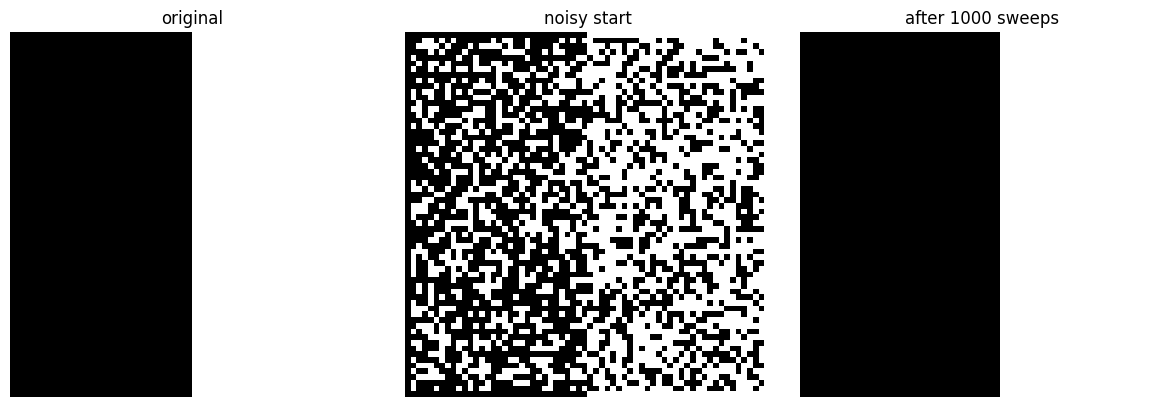

In [40]:
FRAC = 0.4
NOISE_SEED = 15

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final_hybrid = run_hybrid(noisy, seen, PATTERNS)
print("still differing from original:", int((final_hybrid != grid).sum()))
plot_three(grid, noisy, final_hybrid, N)

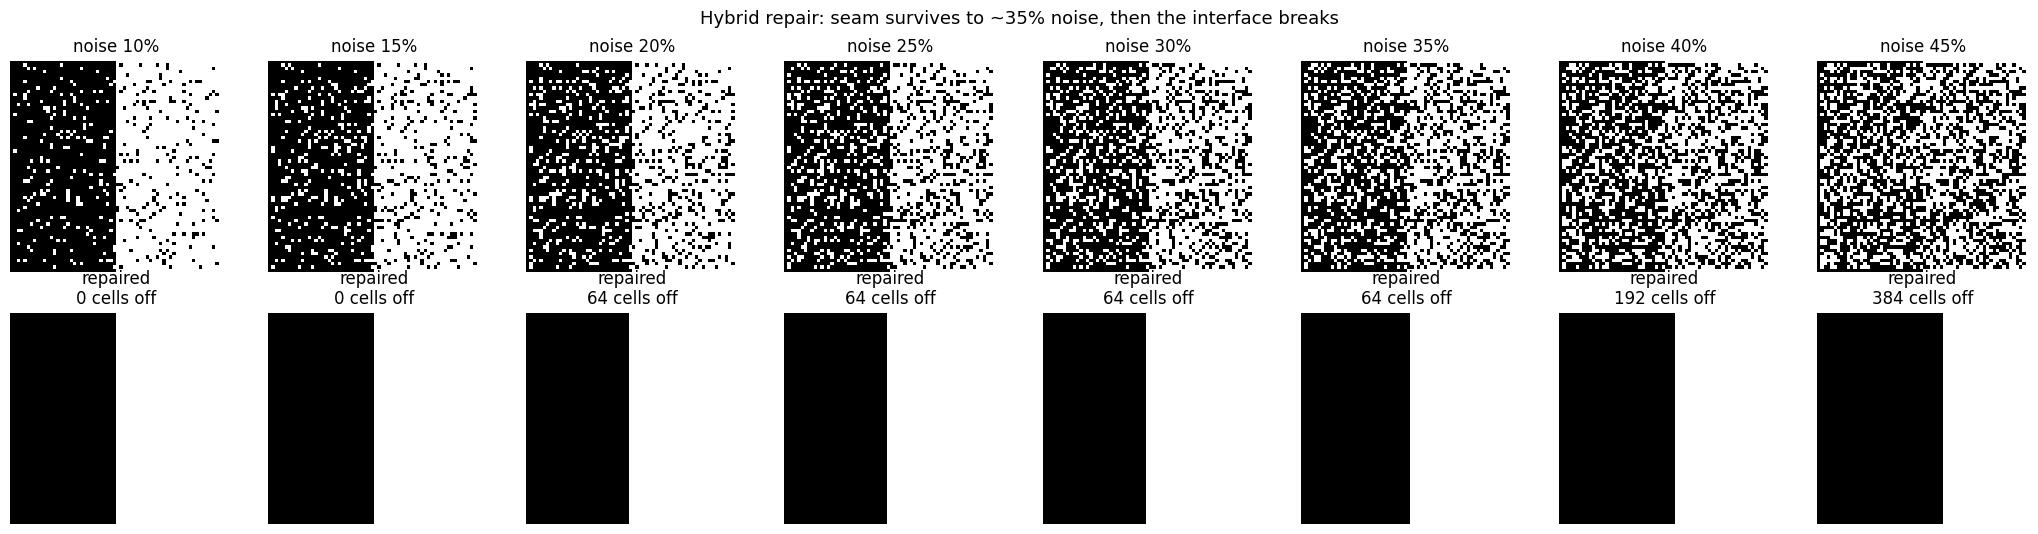

In [41]:
FRACS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]

fig, ax = plt.subplots(2, len(FRACS), figsize=(2.6 * len(FRACS), 5.4))
for j, fr in enumerate(FRACS):
    noisy = add_noise(grid, frac=fr, seed=15)
    out = run_hybrid(noisy, seen, PATTERNS, sweeps=N, seed=SEED, verbose=False)
    ax[0, j].imshow(noisy, cmap="gray", vmin=0, vmax=1)
    ax[0, j].set_title(f"noise {fr:.0%}")
    ax[1, j].imshow(out, cmap="gray", vmin=0, vmax=1)
    ax[1, j].set_title(f"repaired\n{int((out != grid).sum())} cells off")
    for a in (ax[0, j], ax[1, j]):
        a.axis("off")

fig.suptitle("Hybrid repair: seam survives to ~35% noise, then the interface breaks",
             fontsize=13)
plt.tight_layout()
plt.show()

As you can see, it mainly repairs perfectly as we get up to 20%. From 20% onwards, we have one slice down the middle that is incorrect, and then once we get 40%, the shape is gone. 

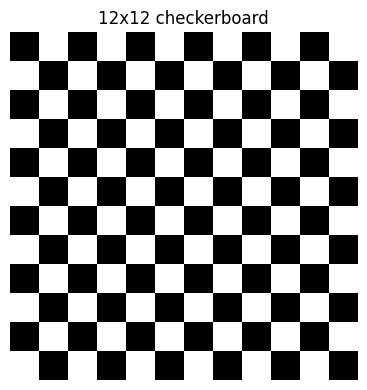

In [43]:
def make_checker(size=12):
    """Checkerboard: cell is 1 when row+col is odd."""
    r = np.arange(size)[:, None]
    c = np.arange(size)[None, :]
    return ((r + c) % 2).astype(int)


grid = make_checker(size=12)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{12}x{12} checkerboard")
plt.axis("off")
plt.tight_layout()
plt.show()

Here's our checkerboard pattern. I'm now going to run our split rules on this checkerboard pattern just to see what outputs. 

still differing from original: 72


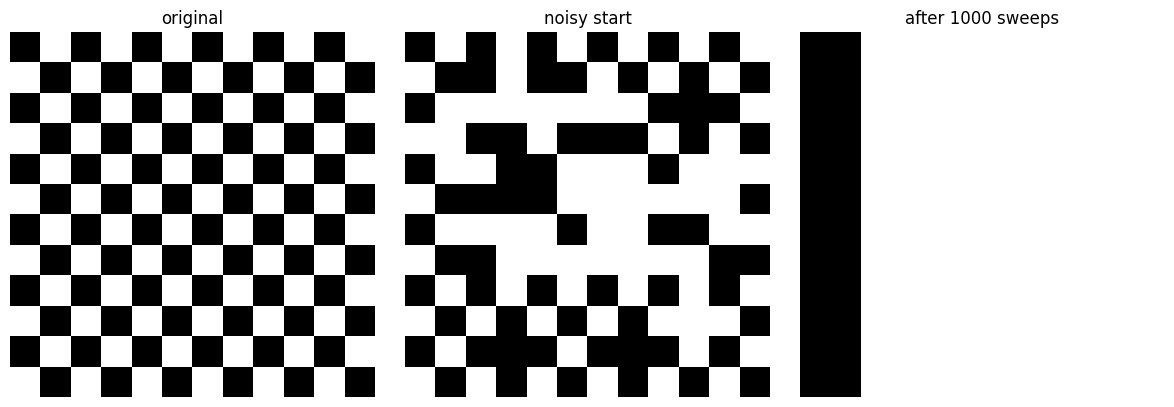

In [51]:
FRAC = 0.40
NOISE_SEED = 0

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final = run_hybrid(noisy, seen, PATTERNS, sweeps=N, seed=SEED, verbose=False)
print("still differing from original:", int((final != grid).sum()))
plot_three(grid, noisy, final, N)

Now we are going to try to make the checkable pattern be recreatable when we add noise. 

In [52]:
grid = make_checker(size=12)
seen = build_windows(grid)
PATTERNS = pattern_array(seen)

print(f"{len(seen)} recognised patterns")   


2 recognised patterns


still differing from original: 144


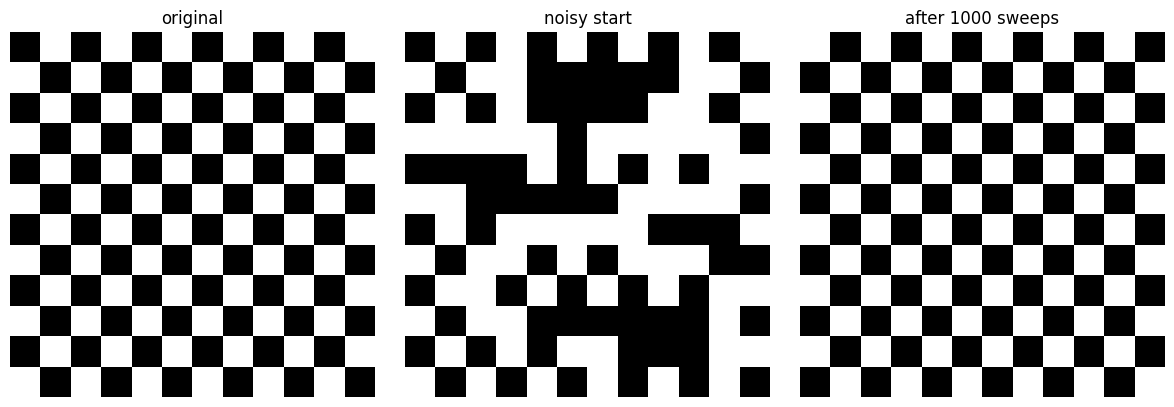

In [61]:
FRAC = 0.5
NOISE_SEED = 15

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final = run_hybrid(noisy, seen, PATTERNS, sweeps=N, seed=SEED, verbose=False)
print("still differing from original:", int((final != grid).sum()))
plot_three(grid, noisy, final, N)

cells differing from original: 0


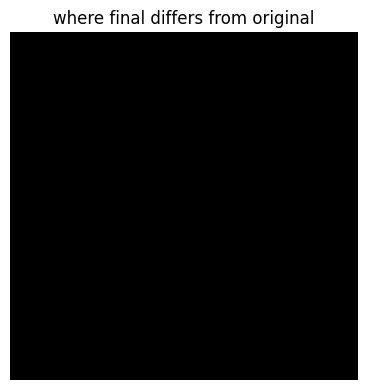

In [60]:
diff = (final != grid)
print("cells differing from original:", int(diff.sum()))

plt.figure(figsize=(4, 4))
plt.imshow(diff, cmap="gray", vmin=0, vmax=1)   # white where it differs, black where it matches
plt.title("where final differs from original")
plt.axis("off")
plt.tight_layout()
plt.show()

As you can see, this works well and recreates a perfect checkerboard. As we push the fraction of noise up higher, we actually see that the board flips and it recreates it perfectly, but white goes where black was and vice versa. 

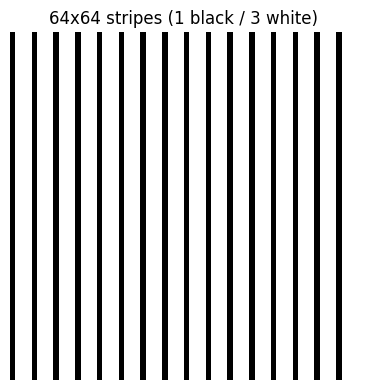

In [74]:
def make_stripes(size, black, white, horizontal=True):
    """Repeating bands: `black` rows/cols of 0, then `white` of 1, repeated."""
    period = black + white
    idx = np.arange(size)
    band = np.where(idx % period < black, 0, 1)     # 0 for first `black`, else 1
    if horizontal:
        g = np.repeat(band[:, None], size, axis=1)
    else:
        g = np.repeat(band[None, :], size, axis=0)
    return g.astype(int)


BLACK = 1        # width of each black band
WHITE = 3       # width of each white band
HORIZONTAL = False 

grid = make_stripes(size, black=BLACK, white=WHITE, horizontal=HORIZONTAL)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{size}x{size} stripes ({BLACK} black / {WHITE} white)")
plt.axis("off")
plt.tight_layout()
plt.show()

4 recognised patterns
differing from original: 256


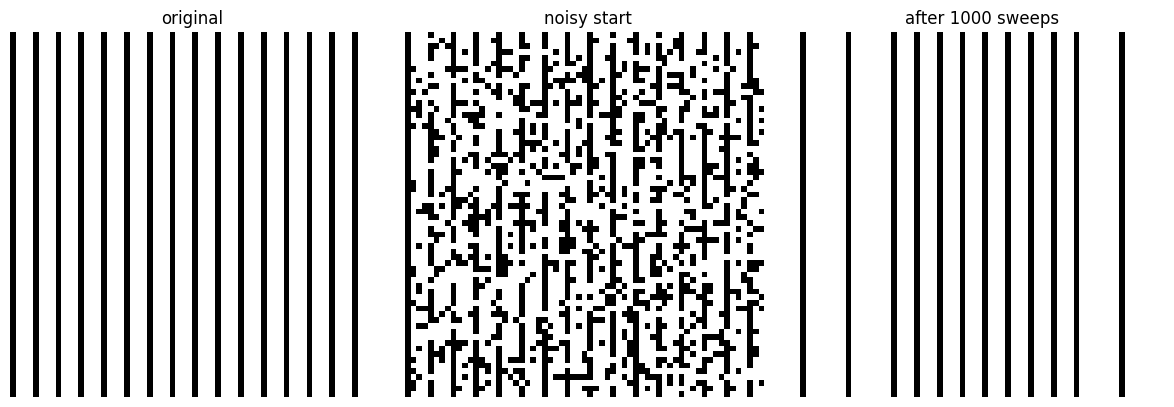

In [76]:
seen = build_windows(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

FRAC = 0.2
NOISE_SEED = 15
noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final = run_hybrid(noisy, seen, PATTERNS, sweeps=N, seed=SEED, verbose=False)

diff = (final != grid)
print("differing from original:", int(diff.sum()))
plot_three(grid, noisy, final, N)

Post-meeting with Evan. 

Now trying periodic boundaries ,And periodic patterns 

In [29]:
import numpy as np
import matplotlib.pyplot as plt

N = 500      
SEED = 15    

Collect all patterns and wrap boundary. 

In [30]:
def win_key(w):
    """The nine cells of a 3x3 window, row-major, as a tuple (hashable key)."""
    return tuple(int(x) for x in w.ravel())


def build_windows_periodic(grid):
    """Every 3x3 pattern in the grid, reading neighbours with wrap-around.
    Covers all rows*cols cells, not just the interior."""
    pad = np.pad(grid, 1, mode="wrap")
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows + 1):
        for c in range(1, cols + 1):
            seen.add(win_key(pad[r - 1:r + 2, c - 1:c + 2]))
    return seen


def pattern_array(seen):
    """Recognised patterns as a (P, 3, 3) int array, in sorted order."""
    return np.array([np.array(p, dtype=int).reshape(3, 3) for p in sorted(seen)])

Here we're making the grid with the circle, checkered and lines. 

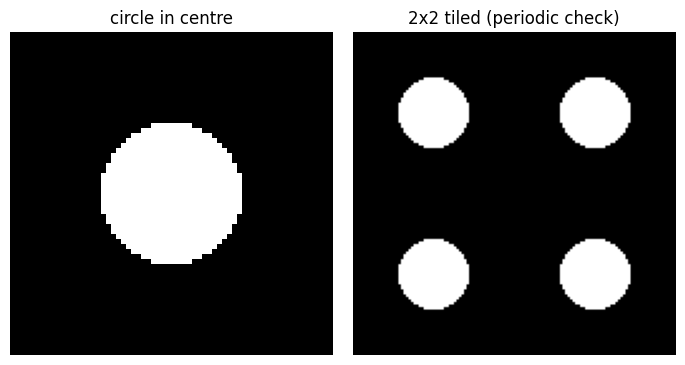

In [31]:
def make_circle(size, radius):
    """Filled disk (1) centred in a field of 0. Uniform border, so it tiles."""
    yy, xx = np.mgrid[0:size, 0:size]
    cy = cx = (size - 1) / 2
    return ((yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2).astype(int)


def make_checker(size=12):
    """Checkerboard; tiles cleanly when size is even."""
    r = np.arange(size)[:, None]
    c = np.arange(size)[None, :]
    return ((r + c) % 2).astype(int)


def make_stripes(size, black, white, horizontal=True):
    """Repeating bands; tiles cleanly when size % (black + white) == 0."""
    period = black + white
    idx = np.arange(size)
    band = np.where(idx % period < black, 0, 1)
    if horizontal:
        return np.repeat(band[:, None], size, axis=1).astype(int)
    return np.repeat(band[None, :], size, axis=0).astype(int)


def show_tiled(grid, title):
    fig, ax = plt.subplots(1, 2, figsize=(7, 3.6))
    ax[0].imshow(grid, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(title)
    ax[1].imshow(np.tile(grid, (2, 2)), cmap="gray", vmin=0, vmax=1)
    ax[1].set_title("2x2 tiled (periodic check)")
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()


show_tiled(make_circle(64, 14), "circle in centre")

Same logic before if it's a recognized pattern. We leave it. If it is unrecognized, we flip the center until it is recognized. If it is not, we use the hybrid approach. 

In [32]:
def nearest_pattern(w, patterns):
    """Recognised pattern closest to window w by Hamming distance.
    Ties: change the centre as little as possible, then lowest sorted order."""
    diffs = (patterns != w).reshape(len(patterns), -1).sum(axis=1)
    cands = np.where(diffs == diffs.min())[0]
    if len(cands) > 1:
        centre_change = (patterns[cands, 1, 1] != w[1, 1]).astype(int)
        cands = cands[centre_change == centre_change.min()]
    return patterns[cands[0]]


def sweep_sync(field, seen, patterns, mode="hybrid"):
    """One synchronous sweep with periodic boundaries.
    mode='center' -> Method 1 only; mode='hybrid' -> Method 1 + nearest-pattern fallback."""
    rows, cols = field.shape
    pad = np.pad(field, 1, mode="wrap")
    nxt = field.copy()
    for r in range(rows):
        for c in range(cols):
            w = pad[r:r + 3, c:c + 3]          # periodic 3x3 of (r, c)
            if win_key(w) in seen:
                continue
            trial = w.copy()
            trial[1, 1] ^= 1                    # try flipping just the centre
            if win_key(trial) in seen:
                nxt[r, c] = trial[1, 1]
                continue
            if mode == "hybrid":               # fallback: centre of nearest pattern
                nxt[r, c] = int(nearest_pattern(w, patterns)[1, 1])
    return nxt, int((nxt != field).sum())


def run_sync(field, seen, patterns, mode="hybrid", sweeps=N, verbose=True):
    """Repeat synchronous sweeps until a fixed point or 2-cycle. Input is never modified."""
    f = field.copy()
    prev2 = None
    for t in range(1, sweeps + 1):
        nxt, changed = sweep_sync(f, seen, patterns, mode)
        if changed == 0:
            if verbose:
                print(f"fixed point at sweep {t}")
            return nxt
        if prev2 is not None and np.array_equal(nxt, prev2):
            if verbose:
                print(f"2-cycle at sweep {t}")
            return nxt
        prev2 = f
        f = nxt
    if verbose:
        print("hit sweep cap")
    return f

Adding noise. 

In [33]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of ALL cells (no protected border now)."""
    rng = np.random.default_rng(seed)
    return (field ^ (rng.random(field.shape) < frac)).astype(int)


def plot_three(original, start, final, title=""):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, "repaired")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

58 recognised patterns
Method 1 (centre only) cells off: 2085
Hybrid              cells off: 45


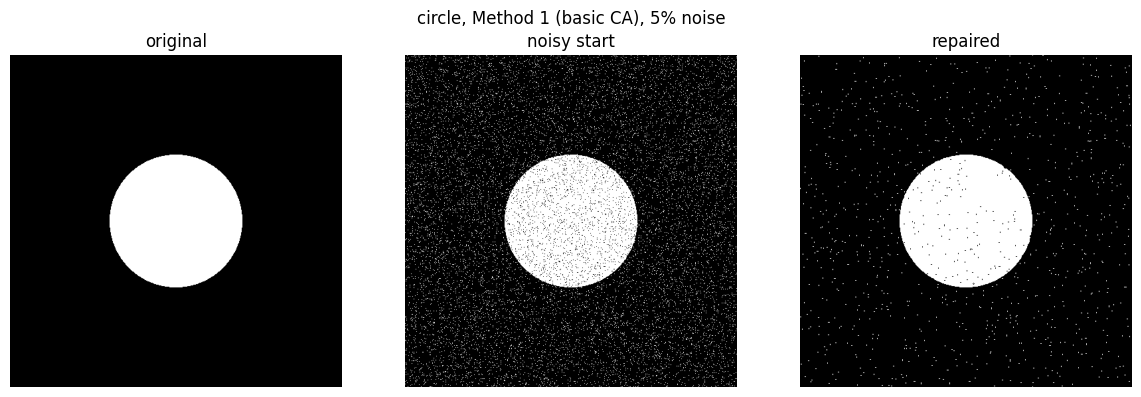

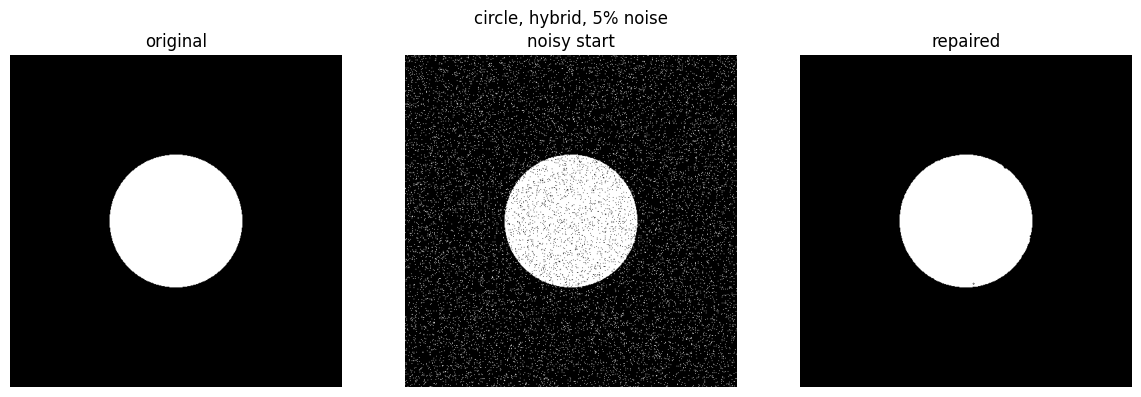

In [40]:
grid = make_circle(size=500, radius=100)
seen = build_windows_periodic(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

FRAC = 0.05
noisy = add_noise(grid, FRAC, seed=SEED)

out_m1 = run_sync(noisy, seen, PATTERNS, mode="center", verbose=False)
out_hy = run_sync(noisy, seen, PATTERNS, mode="hybrid", verbose=False)
print("Method 1 (centre only) cells off:", int((out_m1 != grid).sum()))
print("Hybrid              cells off:", int((out_hy != grid).sum()))

plot_three(grid, noisy, out_m1, f"circle, Method 1 (basic CA), {FRAC:.0%} noise")
plot_three(grid, noisy, out_hy, f"circle, hybrid, {FRAC:.0%} noise")

As we can see, the images look great, but we can still visually see specks appearing. The reason why these are not flagged by the code is that if we zoom into the circle, we can see the rigid edges create patterns of white and black. Those patterns cannot be separated from learned patterns locally, as they are valid patterns, whereas globally we can see it is an issue. 


Making the circle a bigger proportion of the image seems to fix this issue entirely. 

Now we will try on different images, like a random blob. 

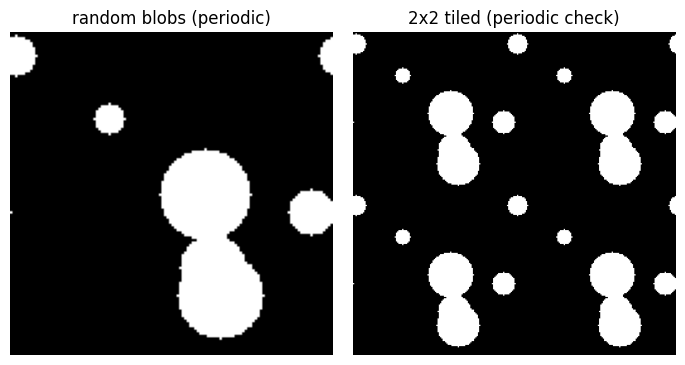

In [42]:
def make_blobs(size, n, rmin, rmax, seed=0):
    """n filled disks of random radius on a torus (wrap-around) -> periodic."""
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:size, 0:size]
    g = np.zeros((size, size), dtype=int)
    for _ in range(n):
        cy, cx = rng.integers(0, size, size=2)
        rad = rng.integers(rmin, rmax + 1)
        dy = np.minimum(np.abs(yy - cy), size - np.abs(yy - cy))
        dx = np.minimum(np.abs(xx - cx), size - np.abs(xx - cx))
        g[dy ** 2 + dx ** 2 <= rad ** 2] = 1
    return g


blobs = make_blobs(size=128, n=8, rmin=6, rmax=18, seed=0)
show_tiled(blobs, "random blobs (periodic)")

77 recognised patterns
46 cells off, 24 of them accepted as valid


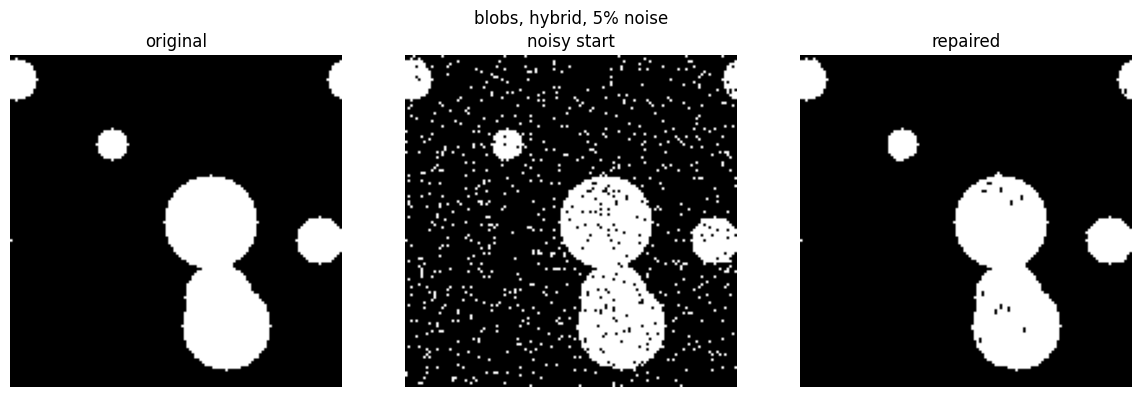

In [46]:
grid = blobs
seen = build_windows_periodic(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

FRAC = 0.05
noisy = add_noise(grid, FRAC, seed=SEED)
out = run_sync(noisy, seen, PATTERNS, mode="hybrid", verbose=False)

diff = out != grid
pad = np.pad(out, 1, mode="wrap")
legal = sum(win_key(pad[r:r + 3, c:c + 3]) in seen for r, c in zip(*np.where(diff)))
print(f"{int(diff.sum())} cells off, {legal} of them accepted as valid")
plot_three(grid, noisy, out, f"blobs, hybrid, {FRAC:.0%} noise")

Having the issue of specks appearing again, this is due to the unique patterns around the edges. To fix this, we will add a simple majority rule. 

In [47]:

def clean_specks(field, thresh=7, rounds=3):
    """Flip a cell only if >= thresh of its 8 periodic neighbours disagree.
    thresh=7/8 -> only near-surrounded specks & pits; real edges (neighbours
    split) are left alone, so blob outlines don't move."""
    f = field.copy()
    for _ in range(rounds):
        pad = np.pad(f, 1, mode="wrap")
        white_nb = (pad[:-2, :-2] + pad[:-2, 1:-1] + pad[:-2, 2:] +
                    pad[1:-1, :-2]                 + pad[1:-1, 2:] +
                    pad[2:, :-2]  + pad[2:, 1:-1]  + pad[2:, 2:])
        black_nb = 8 - white_nb
        flip_white = (f == 1) & (black_nb >= thresh)   # white speck in black
        flip_black = (f == 0) & (white_nb >= thresh)   # black pit in white
        f = np.where(flip_white, 0, np.where(flip_black, 1, f))
    return f

hybrid alone off: 46
hybrid+cleanup off: 23


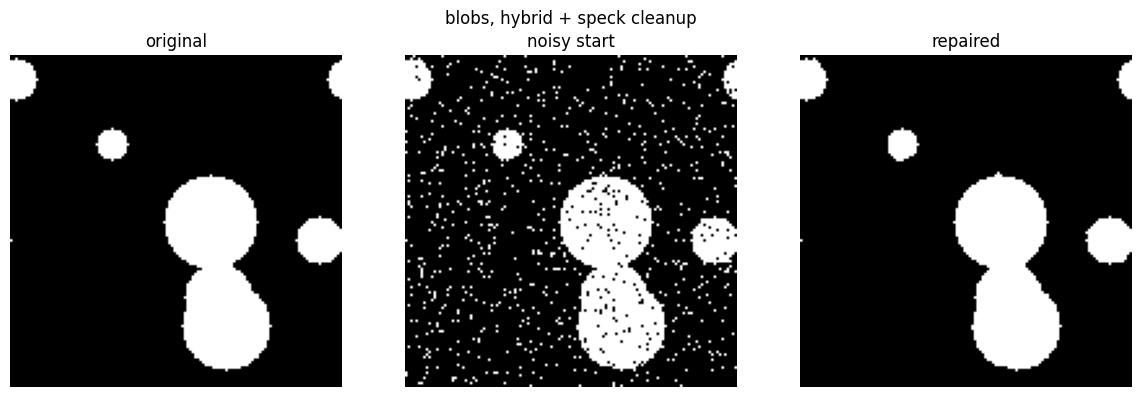

In [51]:
out = run_sync(noisy, seen, PATTERNS, mode="hybrid", verbose=False)
clean = clean_specks(out, thresh=7, rounds=3)
print("hybrid alone off:", int((out != grid).sum()))
print("hybrid+cleanup off:", int((clean != grid).sum()))
plot_three(grid, noisy, clean, "blobs, hybrid + speck cleanup")

Now I'm moving from fixed shapes to a random two-phase field. 

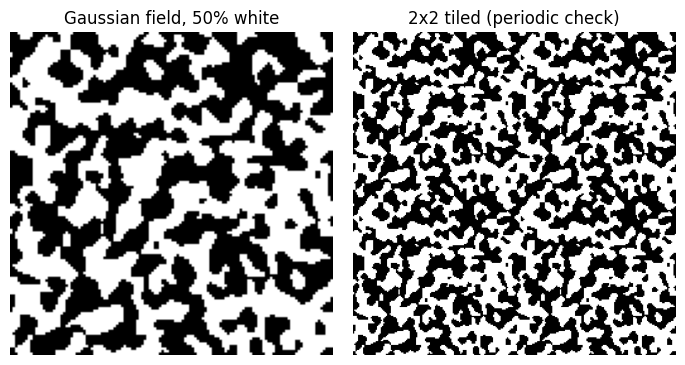

actual white fraction: 0.5


In [55]:
def make_field(size, scale, frac=0.5, seed=0):
    """Smooth periodic Gaussian field thresholded to a target phase fraction.
    frac = fraction of cells that end up white (1). frac=0.5 -> even split."""
    rng = np.random.default_rng(seed)
    white = rng.normal(size=(size, size))
    fx = np.fft.fftfreq(size)[:, None]
    fy = np.fft.fftfreq(size)[None, :]
    freq2 = fx ** 2 + fy ** 2
    filt = np.exp(-((2 * np.pi) ** 2) * freq2 * (scale ** 2) / 2.0)
    field = np.fft.ifft2(np.fft.fft2(white) * filt).real
    thresh = np.quantile(field, 1 - frac)        # keep the top `frac` as white
    return (field > thresh).astype(int)


field = make_field(size=128, scale=2, frac=0.5, seed=0)   # ~30% white
show_tiled(field, "Gaussian field, 50% white")
print("actual white fraction:", field.mean().round(3))

189 recognised patterns
hybrid          off: 400
hybrid + cleanup off: 383


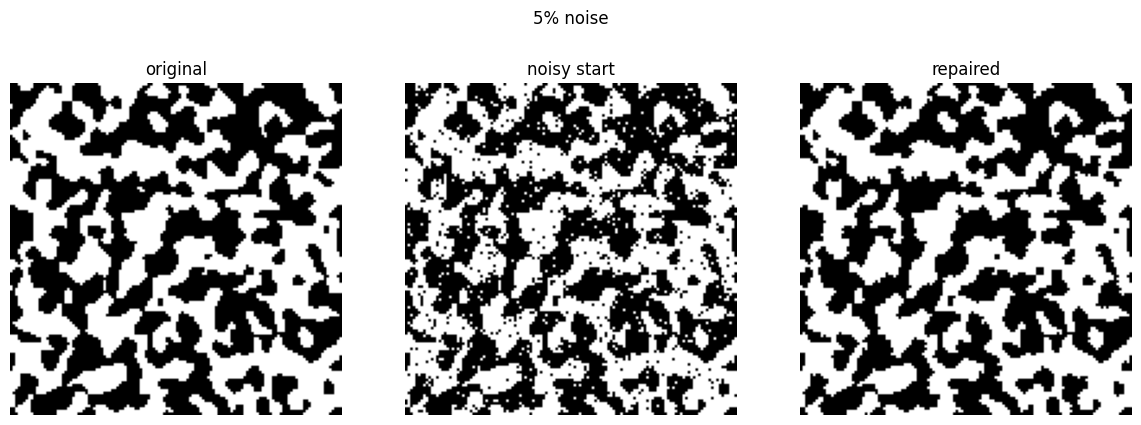

In [61]:
grid = field
seen = build_windows_periodic(grid)
PATTERNS = pattern_array(seen)
print(f"{len(seen)} recognised patterns")

FRAC = 0.05
noisy = add_noise(grid, FRAC, seed=SEED)
out = run_sync(noisy, seen, PATTERNS, mode="hybrid", verbose=False)
clean = clean_specks(out, thresh=7, rounds=3)

print("hybrid          off:", int((out != grid).sum()))
print("hybrid + cleanup off:", int((clean != grid).sum()))
plot_three(grid, noisy, clean, f"{FRAC:.0%} noise")

383 cells off (2.34%)


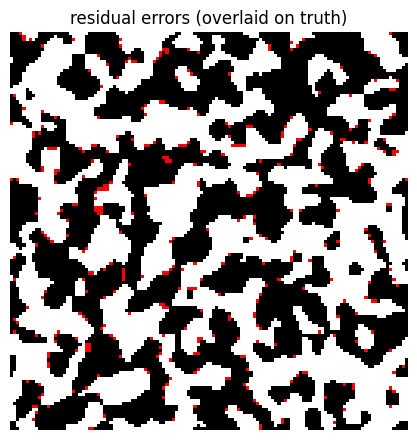

In [62]:
diff = clean != grid
print(f"{diff.sum()} cells off ({diff.mean():.2%})")
plt.figure(figsize=(4.5, 4.5))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.imshow(np.ma.masked_where(~diff, diff), cmap="autumn")
plt.title("residual errors (overlaid on truth)")
plt.axis("off"); plt.tight_layout(); plt.show()

As we can see, the new method of the hybrid approach plus the clean-up stores the field almost perfectly by the way, and then 2.34% of cells remain off at 5% noise. This is largely at the boundary areas. Some, not, but mostly at the boundary areas. Now it's time to maybe fix this or decide where to go next. 

I'm just going to score by statistics rather than just pure pixel. Need to look at the proportion and density and two-point conversion and stuff. Just to make sure that the underlying Gaussian field is actually the same. It looks visually the same, but obviously the amount of pixel difference doesn't necessarily tell us that. 

truth      proportion=0.500   interface=0.115
noisy      proportion=0.499   interface=0.191
repaired   proportion=0.503   interface=0.121


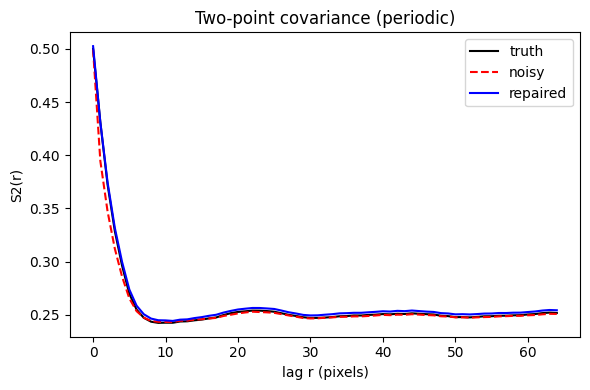

In [63]:
def interface_density(f):
    """Fraction of periodic neighbour pairs that differ (boundary-length proxy)."""
    right = (f != np.roll(f, -1, axis=1)).mean()
    down  = (f != np.roll(f, -1, axis=0)).mean()
    return 0.5 * (right + down)


def two_point_corr(f, rmax=None):
    """Radially-averaged two-point covariance S2(r) via periodic FFT autocorrelation."""
    n = f.size
    F = np.fft.fft2(f)
    ac = np.fft.fftshift(np.fft.ifft2(F * np.conj(F)).real / n)   # S2 at every lag
    size = f.shape[0]
    c = size // 2
    yy, xx = np.mgrid[0:size, 0:size]
    rr = np.hypot(yy - c, xx - c).astype(int)
    if rmax is None:
        rmax = size // 2
    S2 = np.array([ac[rr == r].mean() for r in range(rmax + 1)])
    return np.arange(rmax + 1), S2


for name, img in [("truth", grid), ("noisy", noisy), ("repaired", clean)]:
    print(f"{name:9s}  proportion={img.mean():.3f}   interface={interface_density(img):.3f}")

r, s_truth = two_point_corr(grid)
_, s_noisy = two_point_corr(noisy)
_, s_rep   = two_point_corr(clean)

plt.figure(figsize=(6, 4))
plt.plot(r, s_truth, "k-",  label="truth")
plt.plot(r, s_noisy, "r--", label="noisy")
plt.plot(r, s_rep,   "b-",  label="repaired")
plt.xlabel("lag r (pixels)"); plt.ylabel("S2(r)")
plt.title("Two-point covariance (periodic)")
plt.legend(); plt.tight_layout(); plt.show()

So far, we've just been restoring images after adding noise. So I just wanna test if we can actually grow materials with the learned rules. May not work, just something I want to try. 

2-cycle at sweep 14
truth       proportion=0.500  interface=0.115
seed noise  proportion=0.491  interface=0.501
grown       proportion=0.513  interface=0.247


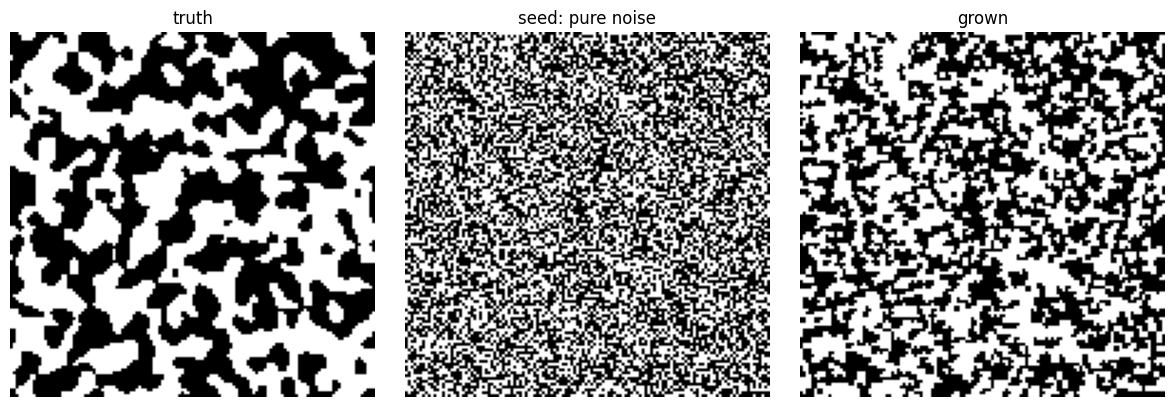

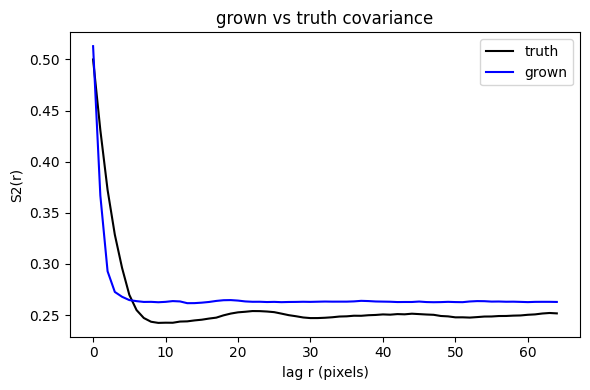

In [66]:
SWEEPS = 100000  

rng = np.random.default_rng(SEED)
seed_noise = (rng.random(grid.shape) < 0.5).astype(int)   # pure 50/50 static

grown = run_sync(seed_noise, seen, PATTERNS, mode="hybrid", sweeps=SWEEPS, verbose=True)
grown = clean_specks(grown, thresh=7, rounds=3)

for name, img in [("truth", grid), ("seed noise", seed_noise), ("grown", grown)]:
    print(f"{name:11s} proportion={img.mean():.3f}  interface={interface_density(img):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (t, img) in zip(ax, [("truth", grid), ("seed: pure noise", seed_noise), ("grown", grown)]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

r, s_t = two_point_corr(grid)
_, s_g = two_point_corr(grown)
plt.figure(figsize=(6, 4))
plt.plot(r, s_t, "k-", label="truth"); plt.plot(r, s_g, "b-", label="grown")
plt.xlabel("lag r (pixels)"); plt.ylabel("S2(r)"); plt.title("grown vs truth covariance")
plt.legend(); plt.tight_layout(); plt.show()

Growing from pure noise, collapsing to blobs like I thought would happen. So I'm going to try to shrink the field and grow there. each 3-pixel neighborhood now spans K real pixels., the blobs come out k times bigger, then upsize it so we will have a blobby-looking image, and then run again. 

In [71]:
def block_downsample(f, k):
    """Shrink by k via block majority. Works for any k (periodic pad to a multiple)."""
    n = f.shape[0]
    sc = -(-n // k)                      # ceil(n/k)
    pad = sc * k - n
    fp = np.pad(f, ((0, pad), (0, pad)), mode="wrap")
    return (fp.reshape(sc, k, sc, k).mean(axis=(1, 3)) > 0.5).astype(int)

def upsample(f, k, out):
    """Blow up by k, then crop back to `out` size."""
    up = np.repeat(np.repeat(f, k, axis=0), k, axis=1)
    return up[:out, :out]

fixed point at sweep 12
fixed point at sweep 1
truth                  proportion=0.500  interface=0.115
grown (3x3)            proportion=0.513  interface=0.247
grown (coarse-to-fine) proportion=0.455  interface=0.086


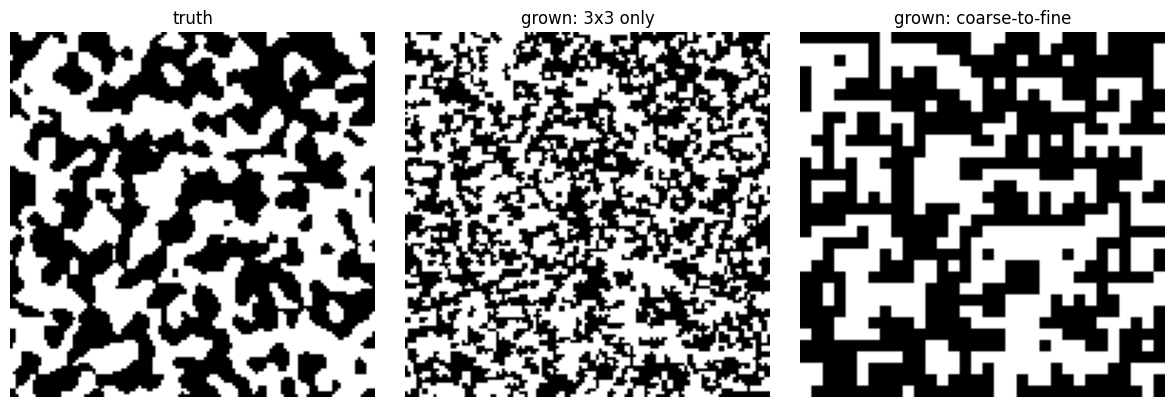

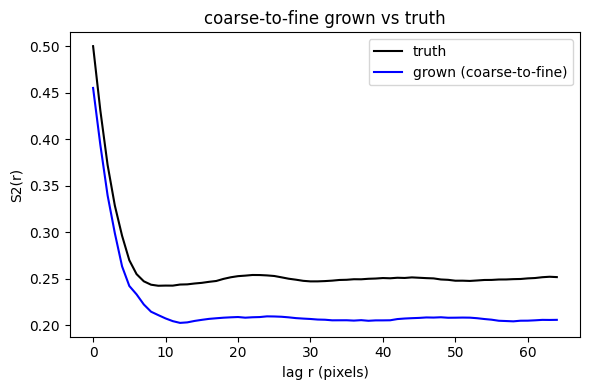

In [72]:
K = 4   # coarsening factor: grown blobs come out ~K x bigger. Try 3-5.

# --- coarse stage: learn + grow on a shrunken copy ---
coarse_truth = block_downsample(grid, K)
seen_c = build_windows_periodic(coarse_truth)
P_c = pattern_array(seen_c)

rng = np.random.default_rng(SEED)
coarse_seed  = (rng.random(coarse_truth.shape) < 0.5).astype(int)   # pure static, coarse grid
coarse_grown = run_sync(coarse_seed, seen_c, P_c, mode="hybrid", sweeps=SWEEPS, verbose=True)

# --- fine stage: upsample the big blobs, refine edges with the fine 3x3 rule ---
seed_fine = upsample(coarse_grown, K, out=grid.shape[0])
grown2 = run_sync(seed_fine, seen, PATTERNS, mode="hybrid", sweeps=SWEEPS, verbose=True)
grown2 = clean_specks(grown2, thresh=7, rounds=3)

for name, img in [("truth", grid), ("grown (3x3)", grown), ("grown (coarse-to-fine)", grown2)]:
    print(f"{name:22s} proportion={img.mean():.3f}  interface={interface_density(img):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (t, img) in zip(ax, [("truth", grid), ("grown: 3x3 only", grown), ("grown: coarse-to-fine", grown2)]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

r, s_t = two_point_corr(grid)
_, s_g = two_point_corr(grown2)
plt.figure(figsize=(6, 4))
plt.plot(r, s_t, "k-", label="truth"); plt.plot(r, s_g, "b-", label="grown (coarse-to-fine)")
plt.xlabel("lag r (pixels)"); plt.ylabel("S2(r)"); plt.title("coarse-to-fine grown vs truth")
plt.legend(); plt.tight_layout(); plt.show()

So we've got the blob size right. So it technically is very similar, but it looks disgusting. Essentially, our boundaries are just dead straight, which is not the case in the real image. So I'm going to try to add a blur to the image so that it hasn't got these straight lines, and then try and fix it from there. 

In [81]:
def smooth_binary(f, scale, frac):
    """Periodic blur + threshold at TARGET proportion `frac` (fixes drift + de-blocks)."""
    n = f.shape[0]
    fx = np.fft.fftfreq(n)[:, None]; fy = np.fft.fftfreq(n)[None, :]
    filt = np.exp(-((2 * np.pi) ** 2) * (fx ** 2 + fy ** 2) * (scale ** 2) / 2.0)
    blurred = np.fft.ifft2(np.fft.fft2(f.astype(float)) * filt).real
    return (blurred > np.quantile(blurred, 1 - frac)).astype(int)

fixed point at sweep 10
fixed point at sweep 3
truth                  proportion=0.500  interface=0.115
grown (3x3)            proportion=0.513  interface=0.247
grown (coarse-to-fine) proportion=0.499  interface=0.106


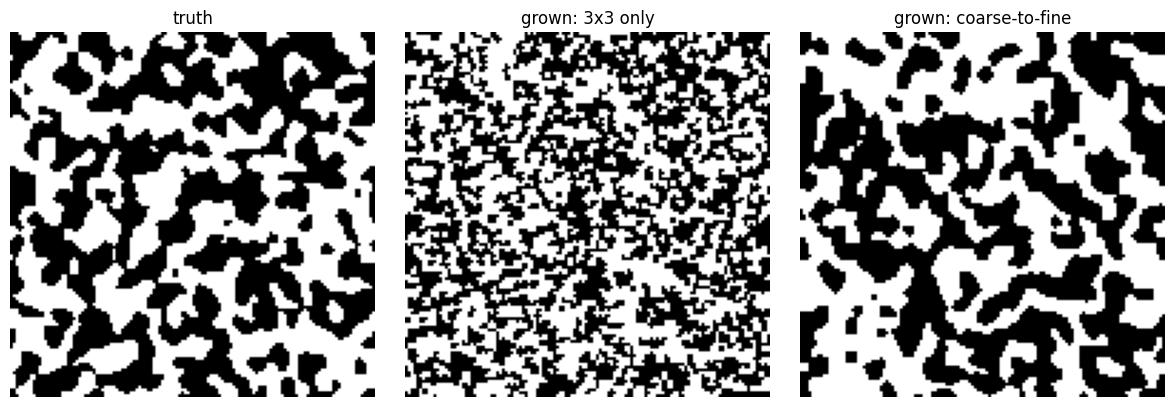

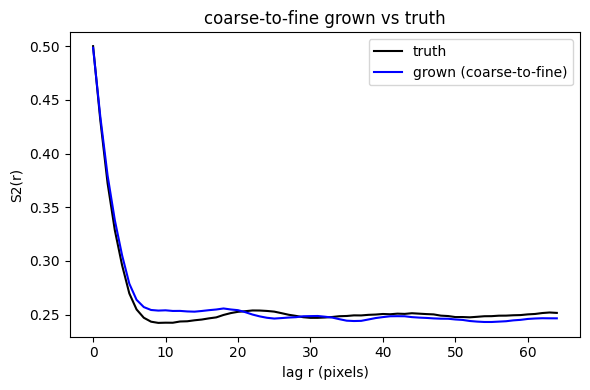

In [83]:
K =2    # drop to k=3 so blobs aren't oversized

coarse_truth = block_downsample(grid, K)
seen_c = build_windows_periodic(coarse_truth)
P_c = pattern_array(seen_c)

rng = np.random.default_rng(SEED)
coarse_seed  = (rng.random(coarse_truth.shape) < 0.5).astype(int)
coarse_grown = run_sync(coarse_seed, seen_c, P_c, mode="hybrid", sweeps=SWEEPS, verbose=True)

seed_fine = upsample(coarse_grown, K, out=grid.shape[0])
seed_fine = smooth_binary(seed_fine, scale=1.5, frac=grid.mean())
grown2 = run_sync(seed_fine, seen, PATTERNS, mode="hybrid", sweeps=SWEEPS, verbose=True)
grown2 = clean_specks(grown2, thresh=7, rounds=3)

for name, img in [("truth", grid), ("grown (3x3)", grown), ("grown (coarse-to-fine)", grown2)]:
    print(f"{name:22s} proportion={img.mean():.3f}  interface={interface_density(img):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (t, img) in zip(ax, [("truth", grid), ("grown: 3x3 only", grown), ("grown: coarse-to-fine", grown2)]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

r, s_t = two_point_corr(grid)
_, s_g = two_point_corr(grown2)
plt.figure(figsize=(6, 4))
plt.plot(r, s_t, "k-", label="truth"); plt.plot(r, s_g, "b-", label="grown (coarse-to-fine)")
plt.xlabel("lag r (pixels)"); plt.ylabel("S2(r)"); plt.title("coarse-to-fine grown vs truth")
plt.legend(); plt.tight_layout(); plt.show()

To the eye they don't look the same, but statistically they're very similar because the measures we matched (proportion, interface, S₂) are low-order and don't capture blob shape or arrangement.